In [49]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated,Literal

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv


load_dotenv()

True

In [50]:
class Task(BaseModel):
    id: int
    title: str
    
    goal: str = Field(
        ... ,
        description="One senctence describing what the reader should be able to do/understand after this section"
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3-5 concrete , non-overlapping subpoints to cover in this section."
    )
    
    target_words: int = Field(
        ...,
        description="Target word count for this section (120-450)"
    )
    
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(...,
              description="Use 'common_mistakes' exactly once in a plan. ")
    

In [51]:
class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description="who is this blog for")
    tone: str = Field(... , description="Writing tone (e.g. practical , crisp).")
    tasks: List[Task]

In [52]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [ ]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-14B-Instruct",
    temperature=0,
    max_new_tokens=1000,
    top_p=0.9
)
llm = ChatHuggingFace(llm=llm)


In [54]:
parser = PydanticOutputParser(pydantic_object=Plan)

In [55]:
template = PromptTemplate(
    template=(
        "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Output must strictly match the Plan schema."
                    "Output MUST be strictly valid JSON.\n"
                    "Do NOT wrap in markdown.\n"
                    "Do NOT include ```json fences.\n"
                    "Do NOT include explanations.\n"
                    "Topic: {topic}\n\n"
                    "{format_instruction}\n"
    ),
    input_variables=['topic'],
    partial_variables={'format_instruction': parser.get_format_instructions()}
)

In [56]:
def orchestrator(state: State) -> dict:
    prompt = template.invoke({'topic': state['topic']})

    for attempt in range(3):  # retry up to 3 times
        result = llm.invoke([
            SystemMessage(
                content="Return strictly valid JSON matching the schema. No markdown."
            ),
            HumanMessage(content=prompt.to_string())
        ]).content

        try:
            plan = parser.parse(result)
            return {"plan": plan}
        except Exception as e:
            print(f"Parse failed (attempt {attempt+1}): {e}")
            continue

    raise ValueError("Failed to generate valid Plan JSON after retries.")


In [57]:
def fanout(state: State):
    return [Send("worker",{"task": task, "topic": state['topic'], "plan": state['plan']})
            for task in state['plan'].tasks]

In [58]:
def worker(payload: dict) -> dict:
    
    task = payload['task']
    topic = payload['topic']
    plan= payload['plan']
    
    blog_title = plan.blog_title
    bullets_text = "\n- " + "\n- ".join(task.bullets)
    
    section_md = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
                    "Hard constraints:\n"
                    "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
                    "- Stay close to the Target words (±15%).\n"
                    "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
                    "Technical quality bar:\n"
                    "- Be precise and implementation-oriented (developers should be able to apply it).\n"
                    "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
                )
                ),
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()
    
    return {"sections":[section_md]}

In [59]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state['plan'].blog_title
    body ="\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"
    
    filename = title.lower().replace(" ","_")+".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")
    
    return {"final": final_md}

In [60]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [61]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout ,["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

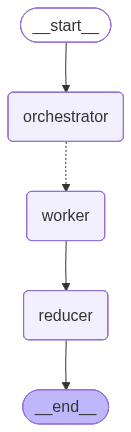

In [62]:
app

In [63]:
out = app.invoke({"topic":"Write a blog on self attention. ", "sections":[]})

In [64]:
out

{'topic': 'Write a blog on self attention. ',
 'plan': Plan(blog_title='Understanding Self Attention Mechanisms', audience='Developers and data scientists interested in deep learning and natural language processing', tone='Practical', tasks=[Task(id=1, title='Introduction to Self Attention', goal='Understand the basic concept of self attention.', bullets=['Define self attention and its role in neural networks.', 'Explain how self attention enables models to focus on different parts of input data.', 'Provide a simple analogy or visual representation of self attention.'], target_words=250, section_type='intro'), Task(id=2, title='Mathematical Formulation', goal='Grasp the mathematical formulation of self attention.', bullets=['Introduce key equations and variables used in self attention.', 'Describe the dot product attention mechanism.', 'Discuss query, key, and value vectors in detail.'], target_words=300, section_type='core'), Task(id=3, title='Implementing Self Attention', goal='Learn